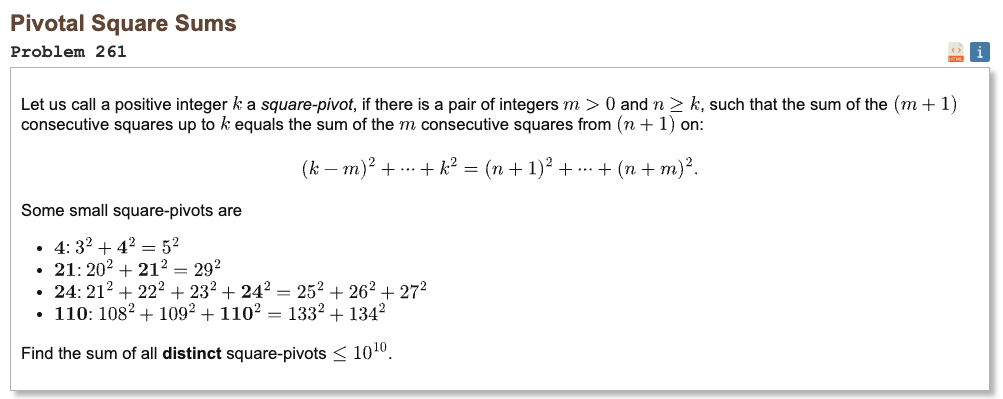

## Initial approach

* use the formula for sum of squares to rewrite the pivot condition as one equation
* reduce that equation to a number theory form that behaves like a Pell equation
* loop over possible values of m, because m must stay below a derived limit
* for each m, extract a squarefree part and build the related Pell equation
* solve the Pell equation using continued fractions to get the fundamental solution
* generate all further solutions from the fundamental one
* from each solution compute a candidate pivot k and check the bounds
* collect all valid distinct k and sum them

In [1]:
import math

LIMIT = 10**10

def build_spf(n):
    spf = list(range(n + 1))
    for i in range(2, math.isqrt(n) + 1):
        if spf[i] == i:
            for j in range(i * i, n + 1, i):
                if spf[j] == j:
                    spf[j] = i
    return spf

def squarefree_and_sqrt(n, spf):
    sf = 1
    sq = 1
    while n > 1:
        p = spf[n]
        e = 0
        while n % p == 0:
            n //= p
            e += 1
        if e % 2 == 1:
            sf *= p
        if e >= 2:
            sq *= p ** (e // 2)
    return sf, sq

def pell_fundamental(D, cache):
    if D in cache:
        return cache[D]
    a0 = math.isqrt(D)
    if a0 * a0 == D:
        raise ValueError("D must be nonsquare")
    m = 0
    d = 1
    a = a0
    num2, num1 = 1, a
    den2, den1 = 0, 1
    while num1 * num1 - D * den1 * den1 != 1:
        m = d * a - m
        d = (D - m * m) // d
        a = (a0 + m) // d
        num2, num1 = num1, a * num1 + num2
        den2, den1 = den1, a * den1 + den2
    cache[D] = (num1, den1)
    return num1, den1

def solve(limit=LIMIT):
    mmax = (math.isqrt(1 + 2 * limit) - 1) // 2
    spf = build_spf(mmax + 2)
    pell_cache = {}
    pivots = set()

    for m in range(1, mmax + 1):
        s, p = squarefree_and_sqrt(m, spf)
        g, r = squarefree_and_sqrt(m + 1, spf)
        D = s * g

        x1, y1 = pell_fundamental(D, pell_cache)

        x = g * r
        y = p

        while True:
            q = y
            numerator = s * p * (p + q)

            if numerator % 2 == 0:
                k = numerator // 2
                if k <= limit and k >= 2 * m * (m + 1):
                    u = x // g
                    t = g * r * u
                    if (t - m - 1) % 2 == 0:
                        n = (t - m - 1) // 2
                        if n >= k:
                            pivots.add(k)

            if (numerator // 2) > limit and q > p:
                break

            x, y = x * x1 + y * y1 * D, x * y1 + y * x1

    for test_k in (4, 21, 24, 110):
        if test_k not in pivots:
            raise ValueError("Missing known pivot: " + str(test_k))

    result = sum(pivots)
    print("Result:", result)
    return result

In [2]:
%%time
solve()

Result: 238890850232021
CPU times: user 200 ms, sys: 6.9 ms, total: 207 ms
Wall time: 207 ms


238890850232021